# Situación 1: NeuroLingua AI

## Contexto del Problema
**NeuroLingua AI** es un modelo de lenguaje avanzado. Queremos entender la relación entre:
1.  **Evaluación Humana (`hum_eval`):** 20 evaluadores califican la calidad de las respuestas (subjetivo).
2.  **Métricas Internas (`int_metric`):** 2,980 métricas técnicas generadas por el modelo (objetivo).

**Objetivo:** Descubrir si existe una estructura latente que conecte la percepción humana con el comportamiento interno del modelo.

## Herramientas
Importamos las librerías esenciales para manipulación de datos y visualización.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jinja2

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [46]:
import os

IMG_PATH = '/home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/'
os.makedirs(IMG_PATH, exist_ok=True)

print(f"Esta es la ruta para los gráficos: {IMG_PATH}")

Esta es la ruta para los gráficos: /home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/


## Paso 2: Carga de Datos

Cargamos el dataset `neuro_lingua_ai.csv` en un DataFrame de pandas. Este archivo contiene las **3,000 observaciones** con las columnas de evaluación humana (`hum_eval`) y métricas internas (`int_metric`).

Visualizamos las primeras 5 filas para verificar que la carga fue correcta.

In [47]:
df = pd.read_csv("/home/yeigen/Documents/proyecto_1_analitica/situacion1/data/neuro_lingua_ai.csv")
df.head()

,prompt_id,hum_eval_1,hum_eval_2,hum_eval_3,hum_eval_4,hum_eval_5,hum_eval_6,hum_eval_7,hum_eval_8,hum_eval_9,...,int_metric_2971,int_metric_2972,int_metric_2973,int_metric_2974,int_metric_2975,int_metric_2976,int_metric_2977,int_metric_2978,int_metric_2979,int_metric_2980
0,1,-0.339186,-0.287385,0.728980,0.860822,1.186173,2.184202,1.427158,2.025146,0.992884,...,-0.192521,3.378995,-2.321888,1.960685,2.307434,2.063464,-0.769745,2.306955,0.465841,2.400956
1,2,0.574710,0.308417,0.525689,-1.776930,0.244834,-0.726710,-0.790432,-1.359604,0.137254,...,-2.239109,-0.014281,-3.644794,4.522159,1.913035,5.217038,-1.137459,3.965600,-1.103022,-0.563290
2,3,1.271335,-0.691080,2.078729,1.061050,0.469707,0.083061,0.706240,1.719755,0.550976,...,-1.905571,1.128669,-4.492878,-5.977465,-1.977145,-4.627741,-0.021282,0.085709,1.739209,-2.410995
3,4,-0.906492,0.478097,0.386307,-0.788879,-0.179730,0.677334,-0.508968,0.142613,-0.040164,...,-1.002625,-0.141350,-2.113565,4.067415,3.319028,6.946003,-2.629901,0.538554,1.666984,-1.175855
4,5,-0.102369,0.117190,0.994496,1.092337,-0.332661,0.586530,-0.525498,-2.120068,0.092944,...,2.563492,-0.487197,-4.773471,1.875335,3.157106,1.962328,1.945696,-1.474450,-1.237909,-0.959168


## Paso 3: Inspección Inicial de los Datos (EDA)

Antes de cualquier análisis, necesitamos responder **tres preguntas fundamentales** sobre nuestro dataset:

### ¿Por qué hacemos esto?

| Inspección | Pregunta que responde | ¿Por qué importa? |
|---|---|---|
| **`df.shape`** | ¿Cuántas filas (observaciones) y columnas (variables) tenemos? | Confirma que la carga fue correcta y dimensiona el problema. Con 3,000 columnas, sabemos que estamos ante un problema de **alta dimensionalidad**. |
| **`df.isnull().sum()`** | ¿Hay valores faltantes? | Los valores nulos pueden sesgar estadísticos, romper modelos y generar conclusiones erróneas. Detectarlos temprano nos permite decidir una estrategia (imputar, eliminar, etc.). |
| **`df.describe()`** | ¿Cuál es la distribución de cada variable? | Los estadísticos descriptivos (media, desviación estándar, min, max, cuartiles) revelan **escalas**, **dispersión** y posibles **outliers** antes de graficar. |

> **Nota:** Como el dataset tiene ~3,000 columnas, mostrar `describe()` completo sería ilegible. Mostraremos solo las **primeras 10 columnas** como muestra representativa.

In [48]:
print(f"Dimensiones: {df.shape}")
print(f"  → {df.shape[0]} observaciones (filas)")
print(f"  → {df.shape[1]} variables (columnas)")
print()

total_nulos = df.isnull().sum().sum()

print(f"Valores nulos totales: {total_nulos}")

print("Primeras 20 columnas de describe")
df.iloc[:, :21].describe()

Dimensiones: (200, 3001)
  → 200 observaciones (filas)
  → 3001 variables (columnas)

Valores nulos totales: 0
Primeras 20 columnas de describe


,prompt_id,hum_eval_1,hum_eval_2,hum_eval_3,hum_eval_4,hum_eval_5,hum_eval_6,hum_eval_7,hum_eval_8,hum_eval_9,...,hum_eval_11,hum_eval_12,hum_eval_13,hum_eval_14,hum_eval_15,hum_eval_16,hum_eval_17,hum_eval_18,hum_eval_19,hum_eval_20
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,0.378051,0.394335,0.253932,0.379894,0.278661,0.425872,0.456313,0.471873,0.475830,...,0.733464,0.632633,0.751521,0.635623,0.700707,0.081275,0.038779,-0.045679,-0.015039,0.030703
std,57.879185,1.438376,1.504461,1.511257,1.491479,1.394805,1.306882,1.357984,1.504353,1.331128,...,1.306834,1.202921,1.297377,1.271093,1.293093,1.313852,1.526782,1.299440,1.341717,1.399655
min,1.000000,-2.462599,-3.042135,-3.253189,-2.738223,-3.014163,-2.439553,-2.854412,-3.208383,-1.912119,...,-2.806282,-2.563875,-2.271406,-2.853226,-2.388166,-2.711341,-3.781834,-2.979867,-3.012003,-3.141739
25%,50.750000,-0.769895,-0.554069,-0.800050,-0.725841,-0.693585,-0.414514,-0.505726,-0.572018,-0.448808,...,-0.133707,-0.144699,-0.120330,-0.292411,-0.285961,-0.975832,-1.275336,-1.143158,-0.966969,-1.134849
50%,100.500000,0.264978,0.239024,0.088115,0.313862,0.193679,0.284120,0.360439,0.386420,0.269939,...,0.683712,0.713494,0.767950,0.654402,0.750637,0.200598,0.037133,-0.045128,-0.038575,0.029626
75%,150.250000,1.174035,1.246244,0.976674,1.149259,1.087002,1.008812,1.166449,1.365467,1.016012,...,1.588682,1.466271,1.634203,1.470504,1.614953,1.108340,1.245766,1.024287,0.843779,1.133030
max,200.000000,4.358219,4.358219,4.358219,4.358219,4.358219,4.358219,4.358219,4.358219,4.358219,...,4.332852,3.260860,4.014441,3.661943,3.765146,3.120334,3.538611,3.189971,3.274239,2.817638


### Explicación de los Estadísticos Descriptivos (`describe()`)

La función `describe()` de pandas calcula **8 estadísticos** para cada columna numérica. Cada uno responde a una pregunta diferente sobre la distribución de los datos:

---

#### 1. **`count`** — ¿Cuántos datos válidos tenemos?

Cuenta el número de valores **no nulos** en cada columna. Si `count` es menor que el número total de filas (`200`), significa que hay valores faltantes.

> En nuestro caso, todas las columnas tienen `count = 200`, lo cual es consistente con que `df.isnull().sum().sum() = 0`. ✅

---

#### 2. **`mean`** (Media aritmética) — ¿Dónde está el "centro" de los datos?

La media es la suma de todos los valores dividida entre el número de observaciones:

$$
\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

Donde:
- $n$ = número de observaciones (en nuestro caso, 200)
- $x_i$ = cada valor individual de la columna

**¿Qué nos dice?** Nos da el "centro de gravedad" de la distribución. Por ejemplo:
- `hum_eval_1` tiene media $\approx 0.378$, lo que sugiere que los evaluadores tienden ligeramente a dar puntuaciones positivas.
- `prompt_id` tiene media $= 100.5$, que es simplemente el punto medio de la secuencia 1, 2, ..., 200. **No tiene significado analítico.**

⚠️ **Cuidado:** La media es sensible a **outliers** (valores extremos). Un solo valor muy grande o muy pequeño puede desplazarla significativamente.

---

#### 3. **`std`** (Desviación estándar) — ¿Qué tan dispersos están los datos?

La desviación estándar mide cuánto se alejan los valores de la media, en promedio. Pandas usa la **desviación estándar muestral** (con $n-1$ en el denominador, conocida como [corrección de Bessel](https://en.wikipedia.org/wiki/Bessel%27s_correction)):

$$
s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

Donde:
- $\bar{x}$ = media de la muestra
- $n - 1$ = grados de libertad (usamos $n-1$ en lugar de $n$ porque estimamos la varianza a partir de una **muestra**, no de la población completa)

**¿Qué nos dice?**
- **`std` pequeña** → los datos están concentrados cerca de la media.
- **`std` grande** → los datos están muy dispersos.

Por ejemplo:
- Las columnas `hum_eval_*` tienen `std ≈ 1.3 - 1.5`, lo cual indica dispersión moderada alrededor de la media.
- `prompt_id` tiene `std ≈ 57.88`, que es simplemente la desviación de una secuencia uniforme de 1 a 200. **No aporta información útil.**

---

#### 3.1. **Varianza ($s^2$)** — La dispersión al cuadrado

La **varianza** mide la **desviación cuadrática promedio** respecto a la media. Es la base matemática de la desviación estándar — de hecho, `std` es simplemente su raíz cuadrada:

$$
s^2 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n-1}
$$

Donde:
- $x_i$ = cada observación individual
- $\bar{x}$ = media aritmética de la muestra
- $n - 1$ = grados de libertad (corrección de Bessel para muestras)

**¿Qué nos dice?**
- Cuantifica qué tan **lejos** están los datos del centro (la media), elevando las diferencias al cuadrado.
- Al elevar al cuadrado, se logran dos cosas: (1) se **penalizan más** las desviaciones grandes, y (2) se **eliminan los signos** negativos (evitando que desviaciones positivas y negativas se cancelen).

**¿Por qué `describe()` muestra `std` y no la varianza directamente?**
- Porque `std` tiene las **mismas unidades** que los datos originales (ej. si los datos están en metros, `std` está en metros). La varianza estaría en **metros²**, lo cual es menos intuitivo para interpretar.
- La relación es directa: $s = \sqrt{s^2}$, es decir, **`std` = $\sqrt{\text{Varianza}}$**.

> **Ejemplo:** Si `hum_eval_1` tiene `std ≈ 1.4`, entonces su varianza es $1.4^2 \approx 1.96$. Ambas miden dispersión, pero `std` es más fácil de interpretar en el contexto original de los datos.

---

#### 4. **`min`** — ¿Cuál es el valor más pequeño?

El valor mínimo de la columna. Útil para detectar:
- Valores negativos inesperados.
- Errores de captura (ej. un peso de -5 kg).
- El rango inferior de los datos.

---

#### 5. **`25%`** (Primer Cuartil, $Q_1$) — ¿Debajo de qué valor está el 25% de los datos?

El **percentil 25**: el valor que separa el 25% inferior del 75% superior. Esto significa que **1 de cada 4 observaciones** tiene un valor menor o igual a $Q_1$.

---

#### 6. **`50%`** (Mediana, $Q_2$) — ¿Cuál es el valor central?

La **mediana** es el valor que divide los datos exactamente a la mitad: 50% de los datos están por encima y 50% por debajo.

$$
\text{Mediana} =
\begin{cases}
x_{\frac{n+1}{2}} & \text{si } n \text{ es impar} \\
\frac{x_{\frac{n}{2}} + x_{\frac{n}{2}+1}}{2} & \text{si } n \text{ es par}
\end{cases}
$$

**¿Cuándo es más útil que la media?** Cuando hay **outliers**. La mediana es **robusta** (no se ve afectada por valores extremos), mientras que la media sí.

> **Ejemplo de nuestros datos:** Para `hum_eval_1`, la media es $0.378$ y la mediana es $0.265$. La diferencia no es drástica, pero sugiere una ligera **asimetría positiva** (la cola derecha es un poco más larga, "jalando" la media hacia arriba).

---

#### 7. **`75%`** (Tercer Cuartil, $Q_3$) — ¿Debajo de qué valor está el 75% de los datos?

El **percentil 75**: el 75% de las observaciones tienen un valor menor o igual a $Q_3$.

La diferencia $Q_3 - Q_1$ se llama **Rango Intercuartílico (IQR)** y es otra medida de dispersión robusta:

$$
\text{IQR} = Q_3 - Q_1
$$

> El IQR se usa para detectar **outliers**: cualquier valor fuera de $[Q_1 - 1.5 \cdot \text{IQR},\; Q_3 + 1.5 \cdot \text{IQR}]$ se considera atípico.

---

#### 8. **`max`** — ¿Cuál es el valor más grande?

El valor máximo. Junto con `min`, define el **rango** de los datos:

$$
\text{Rango} = \max - \min
$$

> **Observación:** Varias columnas `hum_eval_*` comparten el mismo valor máximo ($4.358219$). Esto podría indicar un **tope** (capping) en las evaluaciones, o simplemente que hay un evaluador que consistentemente da la nota más alta. Es algo a investigar.

---

### 🤔 ¿Es realmente necesario mantener la columna `prompt_id`?

**Respuesta corta: No, para el análisis estadístico no.**

La columna `prompt_id` es un **identificador** — una etiqueta que asigna un número único a cada observación. Veamos por qué es problemática mantenerla como variable numérica:

| Aspecto | Problema |
|---|---|
| **Naturaleza** | Es **metadata** (datos sobre los datos), no una **variable de medición**. Los valores 1, 2, ..., 200 no representan una magnitud ni una escala. |
| **Estadísticos sin sentido** | Su media ($100.5$), su desviación estándar ($57.88$) y sus cuartiles son simplemente artefactos de una secuencia uniforme. No describen ningún fenómeno. |
| **Sesgo en modelos** | Si alimentamos un modelo de ML con `prompt_id` como feature numérica, el modelo podría encontrar **correlaciones espurias** (falsas). Por ejemplo: "los prompts con ID alto tienen mejores evaluaciones" — una coincidencia del ordenamiento, no una relación real. |
| **Inflación dimensional** | En un dataset de alta dimensionalidad (3,001 columnas), cada variable innecesaria aumenta el **ruido** y la complejidad computacional. |

**Recomendación:** Tenemos dos opciones para el próximo paso:
1. **Eliminarla** (`df.drop(columns=['prompt_id'])`): si no la necesitamos para rastrear observaciones.
2. **Usarla como índice** (`df.set_index('prompt_id')`): si queremos conservarla como referencia sin que interfiera con los cálculos.

> ⏭️ En el siguiente paso decidiremos cuál aplicar y continuaremos con la exploración visual de las distribuciones.

## Paso 4: Limpieza de Datos — Tratamiento de `prompt_id`

En el paso anterior identificamos que `prompt_id` es un **identificador**, no una variable de medición. Mantenerla como columna numérica es peligroso por una razón fundamental:

### El problema: los algoritmos no entienden "etiquetas"

Los modelos de Machine Learning y las funciones estadísticas tratan **todas las columnas numéricas como variables cuantitativas**. Esto significa que si dejamos `prompt_id` como está:

- Un algoritmo podría interpretar que **ID 200 > ID 1** implica alguna relación de magnitud (ej. "el prompt 200 es 200 veces algo que el prompt 1").
- Funciones como `describe()`, `corr()`, `mean()` calcularán estadísticos sobre ella como si fueran datos reales — generando **ruido** en nuestro análisis.
- En modelos de regresión o clustering, `prompt_id` podría generar **correlaciones espurias** que distorsionen los resultados.

### La solución: convertirla en índice

Usaremos `df.set_index('prompt_id')` para:
1. **Sacarla del espacio de variables** — ya no aparecerá en `describe()`, `corr()`, ni será usada por modelos.
2. **Conservarla como referencia** — seguirá visible como etiqueta de cada fila, permitiéndonos rastrear observaciones individuales.
3. **Reducir la dimensionalidad** — pasamos de 3,001 a 3,000 columnas de datos reales.

> **Regla general:** Los identificadores (`id`, `nombre`, `código`) **nunca** deben ser features en un modelo. Siempre deben ser índices, eliminados, o codificados apropiadamente.

In [49]:
# Convertir prompt_id de columna a índice del DataFrame
df.set_index('prompt_id', inplace=True)

df.head()

,hum_eval_1,hum_eval_2,hum_eval_3,hum_eval_4,hum_eval_5,hum_eval_6,hum_eval_7,hum_eval_8,hum_eval_9,hum_eval_10,...,int_metric_2971,int_metric_2972,int_metric_2973,int_metric_2974,int_metric_2975,int_metric_2976,int_metric_2977,int_metric_2978,int_metric_2979,int_metric_2980
prompt_id,,,,,,,,,,,,,,,,,,,,,
1,-0.339186,-0.287385,0.728980,0.860822,1.186173,2.184202,1.427158,2.025146,0.992884,2.309524,...,-0.192521,3.378995,-2.321888,1.960685,2.307434,2.063464,-0.769745,2.306955,0.465841,2.400956
2,0.574710,0.308417,0.525689,-1.776930,0.244834,-0.726710,-0.790432,-1.359604,0.137254,-0.568507,...,-2.239109,-0.014281,-3.644794,4.522159,1.913035,5.217038,-1.137459,3.965600,-1.103022,-0.563290
3,1.271335,-0.691080,2.078729,1.061050,0.469707,0.083061,0.706240,1.719755,0.550976,1.522270,...,-1.905571,1.128669,-4.492878,-5.977465,-1.977145,-4.627741,-0.021282,0.085709,1.739209,-2.410995
4,-0.906492,0.478097,0.386307,-0.788879,-0.179730,0.677334,-0.508968,0.142613,-0.040164,0.000648,...,-1.002625,-0.141350,-2.113565,4.067415,3.319028,6.946003,-2.629901,0.538554,1.666984,-1.175855
5,-0.102369,0.117190,0.994496,1.092337,-0.332661,0.586530,-0.525498,-2.120068,0.092944,0.423968,...,2.563492,-0.487197,-4.773471,1.875335,3.157106,1.962328,1.945696,-1.474450,-1.237909,-0.959168


## Paso 5: Visualización de Distribuciones (Histogramas)

Ahora que nuestros datos están limpios y `prompt_id` ya no interfiere como variable numérica, es momento de **ver** cómo se distribuyen las evaluaciones humanas.

### ¿Qué es un Histograma?

Un **histograma** es un gráfico de barras que muestra la **distribución de frecuencias** de una variable continua. A diferencia de un gráfico de barras clásico (que muestra categorías), el histograma:

1. Divide el **rango** de los datos en **intervalos contiguos** llamados *bins* (contenedores).
2. Cuenta cuántas observaciones **caen dentro** de cada bin.
3. Representa esa frecuencia como la **altura** de cada barra.

### ¿Qué información extraemos de un histograma?

| Característica | ¿Qué observar? | Ejemplo |
|---|---|---|
| **Centro** | ¿Dónde está el **pico** (moda)? ¿Coincide con la media y la mediana? | Si el pico está en $\approx 0.3$, la mayoría de los evaluadores dan puntuaciones alrededor de ese valor. |
| **Dispersión** | ¿Qué tan **ancha** es la distribución? | Una distribución estrecha indica consenso entre evaluadores; una ancha indica opiniones divergentes. |
| **Forma** | ¿Es **simétrica** (tipo campana/Normal)? ¿Tiene **sesgo** a la izquierda o derecha? ¿Es **multimodal** (varios picos)? | Una distribución sesgada a la derecha tiene una "cola" larga hacia valores altos. |

### ¿Cuántos bins usar? — Regla de Sturges

Un histograma puede verse muy diferente dependiendo de cuántos bins elijamos. Una estimación clásica es la **Regla de Sturges**:

$$
k = 1 + 3.322 \cdot \log_{10}(n)
$$

Donde:
- $k$ = número de bins recomendado
- $n$ = número de observaciones

Para nuestro dataset con $n = 200$:

$$
k = 1 + 3.322 \cdot \log_{10}(200) = 1 + 3.322 \cdot 2.301 \approx 1 + 7.64 \approx 8.64 \approx 9 \text{ bins}
$$

> **Nota:** Usaremos `sns.histplot()` con la opción `kde=True`, que además del histograma superpone una **curva KDE** (*Kernel Density Estimation*) — una estimación suavizada de la densidad de probabilidad. Esto nos ayuda a ver la "forma" de la distribución sin depender del número exacto de bins.

### Objetivo

Visualizaremos las **primeras 6 columnas** `hum_eval` en una cuadrícula 2×3 para:
- Verificar si las distribuciones de los evaluadores siguen un **patrón similar** (lo que sugeriría consistencia en las evaluaciones).
- Detectar evaluadores con distribuciones **anómalas** (muy diferentes al resto).
- Confirmar visualmente lo que `describe()` nos mostró numéricamente (media, dispersión, asimetría).

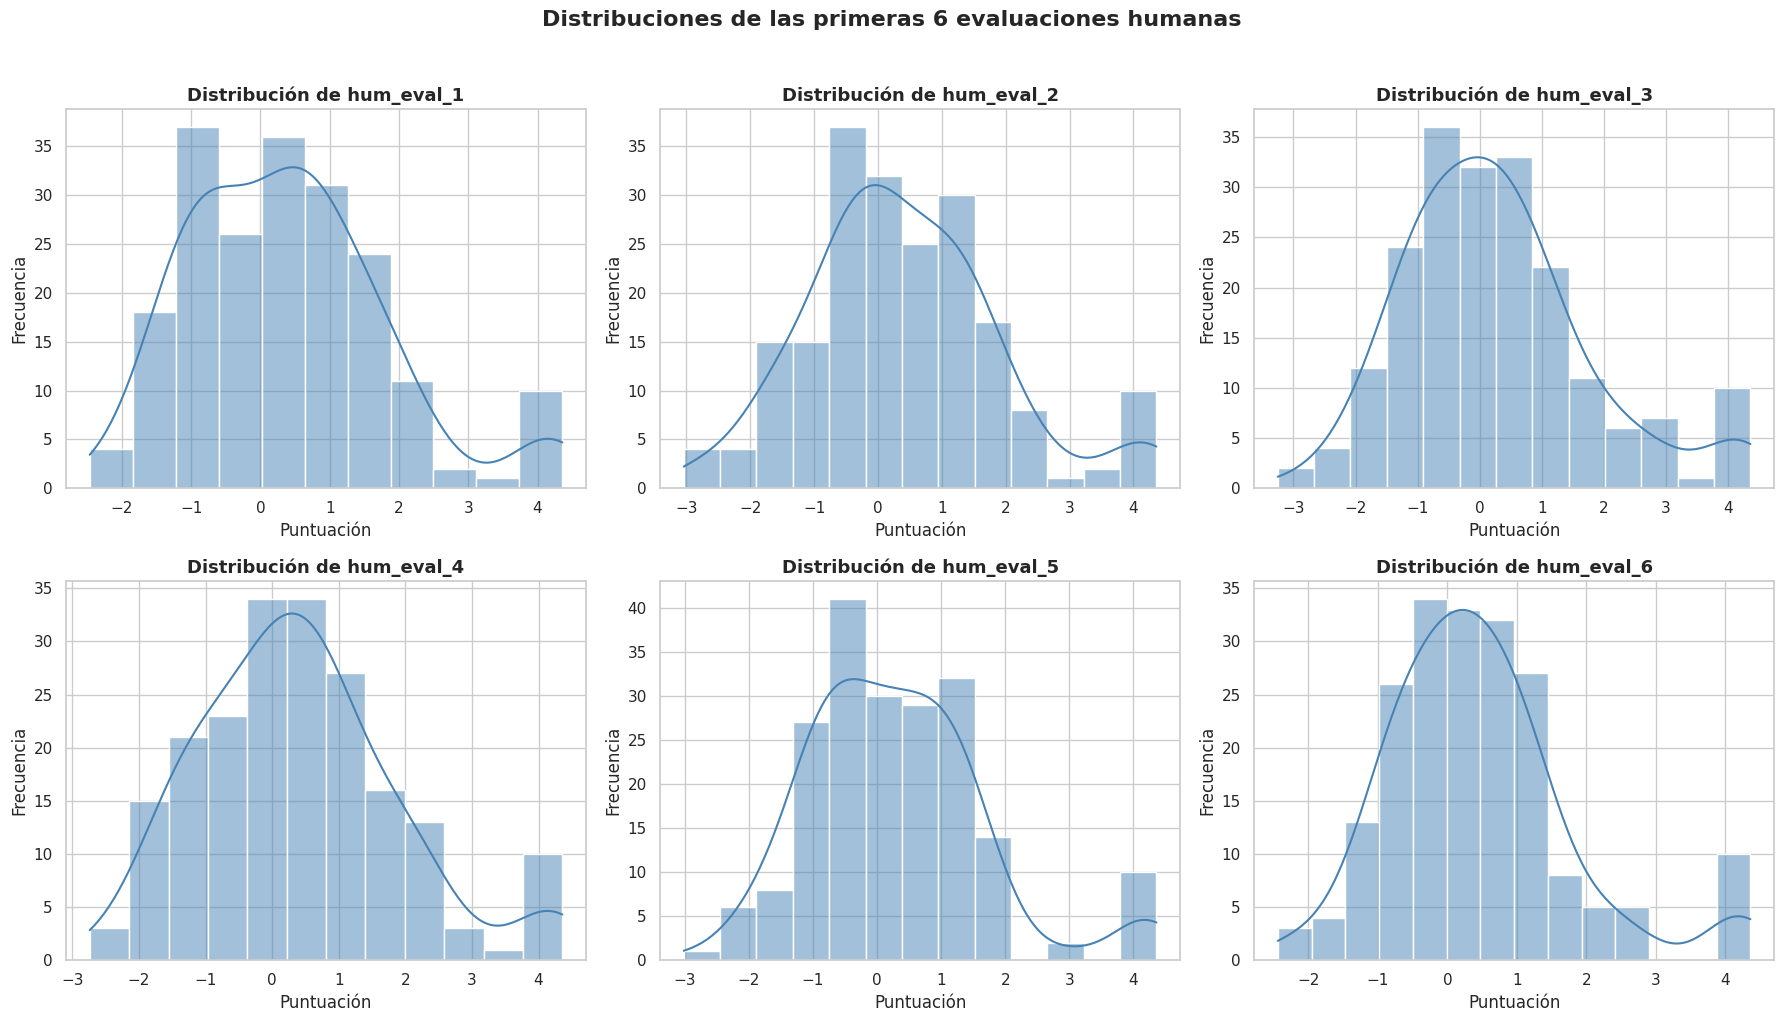

📊 Guardado en: /home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/histograms_first_6.png


In [50]:
hum_eval_cols = [col for col in df.columns if col.startswith('hum_eval')]
cols_to_plot = hum_eval_cols[:6]

# Creamos una cuadrícula 2x3 de subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribución de {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Puntuación')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribuciones de las primeras 6 evaluaciones humanas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{IMG_PATH}histograms_first_6.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Guardado en: {IMG_PATH}histograms_first_6.png")

### Interpretación: Distribuciones de los Primeros 6 Evaluadores

Observemos los 6 histogramas con sus curvas KDE superpuestas y respondamos las preguntas clave:

---

#### 1. ¿Son distribuciones simétricas (forma de campana)?

**Aproximadamente sí, pero no perfectamente.** Las 6 distribuciones presentan una forma general de **campana** (unimodal), lo que sugiere un comportamiento cercano a la **distribución Normal**. Sin embargo, ninguna es perfectamente simétrica:

- En todas ellas, se observa una **cola derecha más larga** que la izquierda — hay puntuaciones que se extienden hasta $\approx 4.0$–$4.4$, mientras que la cola izquierda se detiene alrededor de $-2.5$ a $-3.0$.
- Esta **asimetría positiva** (sesgo a la derecha) confirma lo que `describe()` nos mostró: la media ($\bar{x}$) es ligeramente mayor que la mediana ($Q_2$) en todos los evaluadores.

> **¿Qué significa esto en contexto?** La mayoría de las evaluaciones se concentran alrededor de $0$ (neutral), pero hay un grupo de respuestas del modelo que reciben puntuaciones **excepcionalmente altas** ($> 3$), "jalando" la distribución hacia la derecha.

---

#### 2. ¿Tienen un centro similar?

**Sí.** Los 6 picos (modas) se ubican en la franja de $-0.5$ a $+0.5$, con las curvas KDE alcanzando su máximo cerca de **$0$ a $0.5$**. Esto indica que:

- Los evaluadores **coinciden** en que la mayoría de las respuestas del modelo son de calidad **neutral a ligeramente positiva**.
- No hay evaluadores con el pico desplazado dramáticamente (ej. centrado en $-2$ o en $+3$), lo cual descarta — al menos en esta muestra de 6 — la existencia de un evaluador con un sesgo extremo.

---

#### 3. ¿Tienen una dispersión (spread) similar?

**Razonablemente sí, con matices.** Los 6 histogramas cubren un rango comparable ($\approx -3$ a $+4.5$), pero hay diferencias sutiles:

- `hum_eval_5` parece tener una distribución **ligeramente más concentrada** (más alta y estrecha en el centro), lo que sugiere un evaluador más **consistente** en sus puntuaciones.
- `hum_eval_1` y `hum_eval_6` muestran distribuciones un poco más **aplanadas** (más dispersas), indicando mayor variabilidad en sus juicios.

> **Lectura de la curva KDE:** Cuando la curva KDE es alta y estrecha, el evaluador es predecible (da puntuaciones similares). Cuando es baja y ancha, sus opiniones son más variables.

---

#### Conclusión preliminar

Las primeras 6 distribuciones comparten un **patrón común**: forma de campana, centradas cerca de $0$, con asimetría positiva moderada y rango entre $-3$ y $+4.5$. Esto sugiere que estos evaluadores podrían estar midiendo un **mismo constructo** subyacente (una dimensión de "calidad" compartida). Para confirmarlo, necesitamos ver **los 20 evaluadores** y luego analizar las **correlaciones** entre ellos.

## Paso 6: Visualización Avanzada (Boxplots y Correlación)

### ¿Por qué solo graficamos 6 histogramas antes?

En el paso anterior visualizamos únicamente las **primeras 6 columnas** `hum_eval` en una cuadrícula 2×3. Esto fue una decisión deliberada:

- Con **20 evaluadores**, una cuadrícula de 20 histogramas individuales sería difícil de leer y comparar visualmente.
- El objetivo era **inspeccionar distribuciones individuales con claridad**: verificar forma, centro, dispersión y posibles anomalías evaluador por evaluador.
- 6 columnas son suficientes como **muestra representativa** para confirmar que los evaluadores siguen patrones similares.

### Nuevo objetivo: la visión agregada

Ahora queremos responder una pregunta diferente: **¿Cómo se distribuyen TODAS las evaluaciones humanas en conjunto?** Para esto, "aplanaremos" las 20 columnas `hum_eval` en una sola serie de $200 \times 20 = 4{,}000$ valores y graficaremos un único histograma agregado. Esto nos dará la **tendencia general** de las puntuaciones.

Además, introducimos dos herramientas de visualización nuevas:

---

### Concepto 1: Boxplot (Diagrama de Caja y Bigotes)

Un **boxplot** condensa la distribución de una variable en su **resumen de 5 números**:

| Componente | Estadístico | Descripción |
|---|---|---|
| Línea inferior del bigote | **Mínimo*** | El menor valor dentro del rango aceptable |
| Borde inferior de la caja | **$Q_1$** (Percentil 25) | El 25% de los datos están por debajo |
| Línea dentro de la caja | **Mediana** ($Q_2$) | El valor central (50%) |
| Borde superior de la caja | **$Q_3$** (Percentil 75) | El 75% de los datos están por debajo |
| Línea superior del bigote | **Máximo*** | El mayor valor dentro del rango aceptable |

*\*Los bigotes NO llegan necesariamente al `min` y `max` absolutos.* Su extensión está determinada por la **regla del IQR**:

$$
\text{Bigote inferior} = Q_1 - 1.5 \times IQR \qquad \text{Bigote superior} = Q_3 + 1.5 \times IQR
$$

Donde $IQR = Q_3 - Q_1$ es el **Rango Intercuartílico**.

Cualquier punto **fuera** de estos límites se marca como un **outlier** (punto atípico) — representado como un punto individual más allá de los bigotes.

> **¿Por qué 1.5?** Es una convención propuesta por John Tukey (1977). Si los datos fueran perfectamente normales, este rango capturaría aproximadamente el **99.3%** de las observaciones, dejando solo el 0.7% como outliers.

---

### Concepto 2: Heatmap de Correlación (Pearson)

El **coeficiente de correlación de Pearson** ($r$) mide la **fuerza y dirección** de la relación **lineal** entre dos variables. Su fórmula es:

$$
r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \cdot \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}
$$

Donde:
- $x_i, y_i$ = valores de las dos variables para la observación $i$
- $\bar{x}, \bar{y}$ = medias de cada variable
- El numerador es la **covarianza** (¿se mueven juntas?)
- El denominador es el producto de las **desviaciones estándar** (normalización)

**Interpretación del valor $r$:**

| Rango de $r$ | Interpretación |
|---|---|
| $r = +1$ | Correlación lineal **positiva perfecta** — cuando una sube, la otra sube proporcionalmente |
| $0.7 \leq r < 1$ | Correlación positiva **fuerte** |
| $0.3 \leq r < 0.7$ | Correlación positiva **moderada** |
| $0 < r < 0.3$ | Correlación positiva **débil** |
| $r = 0$ | **Sin correlación lineal** (pueden existir relaciones no lineales) |
| $r < 0$ | Correlación **negativa** (misma escala, dirección opuesta) |

> ⚠️ **Correlación ≠ Causalidad.** Que dos variables estén correlacionadas no significa que una *cause* la otra. Puede haber una tercera variable (confundidora) que explique ambas.

## Paso 6.1: Referencia Detallada — Los 20 Histogramas Individuales

### Aclaración sobre el Heatmap anterior

La **matriz de correlación** que graficamos en el Paso 6 muestra las correlaciones **entre los 20 evaluadores humanos** (`hum_eval` vs `hum_eval`). Es decir, es una matriz de $20 \times 20$ que responde a la pregunta:

> **¿Los evaluadores humanos están de acuerdo entre sí?**

Si dos evaluadores tienen una correlación alta ($r \approx 0.8$), significa que cuando uno da una puntuación alta, el otro también tiende a darla — **coinciden en sus juicios**. Si la correlación es baja ($r \approx 0$), sus evaluaciones son **independientes** (no se parecen).

⚠️ **Lo que NO muestra el heatmap anterior:** La relación entre evaluadores humanos y las métricas internas (`int_metric`). Esa correlación cruzada (`hum_eval` vs `int_metric`) la exploraremos en pasos posteriores, y es clave para responder la pregunta central del proyecto: *¿existe una conexión entre la percepción humana y el comportamiento interno del modelo?*

---

### Nueva Visualización: 20 Histogramas en Cuadrícula 5×4

En el Paso 5 graficamos solo 6 histogramas como muestra representativa. Ahora queremos la **visión completa**: los 20 evaluadores, cada uno con su propia distribución, en una cuadrícula de $5 \times 4$.

### ¿Qué buscar en esta visualización?

| Patrón | ¿Qué significa? | Ejemplo |
|---|---|---|
| **Diferencias en dispersión (spread)** | Algunos evaluadores usan el rango completo de la escala ($-3$ a $+3$), mientras que otros son **conservadores** y se mantienen en un rango estrecho ($-1$ a $+1$). Esto indica diferencias en el **criterio de evaluación**. | Un evaluador con `std ≈ 0.5` vs otro con `std ≈ 2.0`. |
| **Distribuciones bimodales** | Si un histograma tiene **dos picos** separados, el evaluador podría estar dividiendo las respuestas en "buenas" y "malas" sin usar valores intermedios — un comportamiento **polarizado**. | Picos en $-2$ y $+2$ con un valle en $0$. |
| **Sesgo (skewness)** | Si la distribución tiene una cola larga hacia la derecha (sesgo positivo), el evaluador tiende a dar puntuaciones bajas pero ocasionalmente da notas altas. Lo inverso para sesgo negativo. | Media $\neq$ Mediana indica asimetría. |
| **Evaluadores "outlier"** | Si un histograma tiene una forma radicalmente diferente al resto, ese evaluador podría tener un **criterio inconsistente** o estar evaluando con una escala diferente. | Todos unimodales excepto uno que es uniforme. |

> Esta inspección visual complementa los estadísticos de `describe()`. Los números nos dicen *cuánto*, los histogramas nos muestran *cómo*.

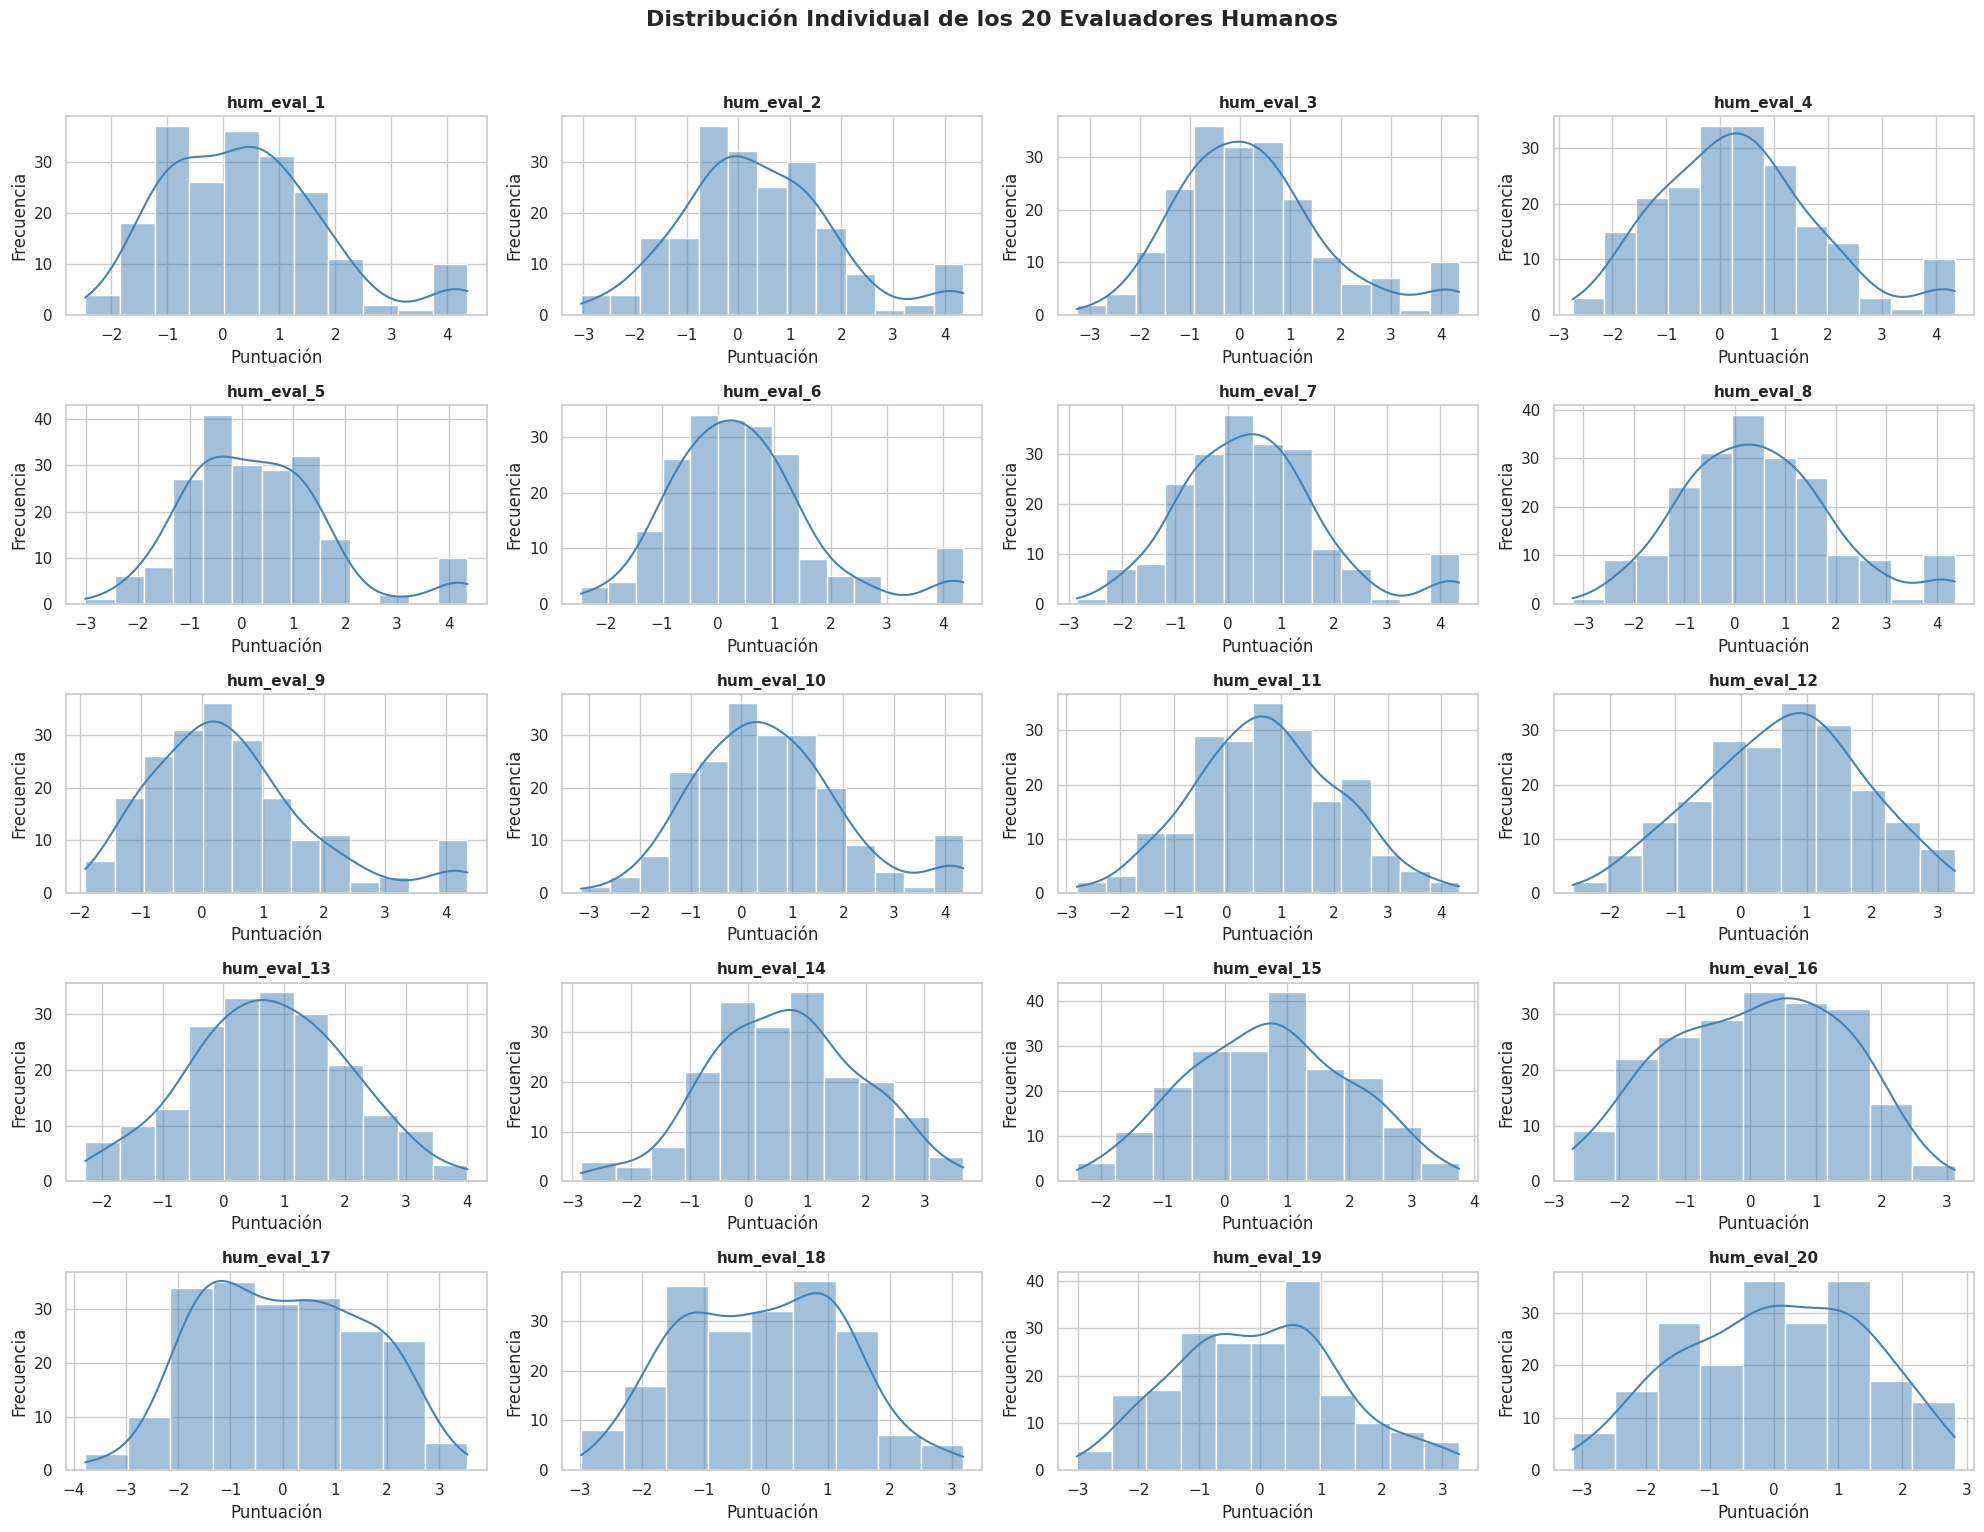

📊 Guardado en: /home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/histograms_all_20.png


In [51]:
# Paso 6.1: Cuadrícula completa de 20 histogramas (5 filas × 4 columnas)
hum_eval_cols = [col for col in df.columns if col.startswith('hum_eval')]

fig, axes = plt.subplots(5, 4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(hum_eval_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Puntuación')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle(
    'Distribución Individual de los 20 Evaluadores Humanos',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(f'{IMG_PATH}histograms_all_20.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Guardado en: {IMG_PATH}histograms_all_20.png")

### Interpretación: Panel Completo de 20 Histogramas

Ahora que tenemos la **visión completa** de los 20 evaluadores, analicemos los patrones que emergen al compararlos todos simultáneamente.

---

#### 1. Forma general: ¿Unimodales o bimodales?

**Todos los 20 histogramas son unimodales** — cada uno tiene un solo pico principal. No se observan distribuciones bimodales (dos picos separados), lo que descarta la hipótesis de evaluadores que "polarizan" sus puntuaciones en dos extremos. Esto es bueno: sugiere que cada evaluador aplica un **criterio consistente** (no cambia de escala a mitad de la evaluación).

---

#### 2. Diferencias en el centro (media/moda)

Observemos **dónde** se ubica el pico de cada distribución:

- **Evaluadores 1–10:** El pico se concentra aproximadamente en $0$ a $0.5$. Estos evaluadores tienen un centro **ligeramente positivo**, lo que indica que tienden a percibir las respuestas del modelo como "levemente buenas".
- **Evaluadores 11–15:** El pico se desplaza un poco más a la derecha, sugiriendo evaluadores algo **más generosos**.
- **Evaluadores 16–20:** Presentan picos más cercanos a $0$ o incluso ligeramente negativos. Evaluadores más **neutros o estrictos**.

> **Patrón emergente:** Parece haber **grupos** de evaluadores con centros similares. Esto será clave cuando analicemos la correlación entre ellos.

---

#### 3. Diferencias en dispersión (spread/anchura)

No todos los evaluadores usan la escala con la misma amplitud:

- **Evaluadores más concentrados** (distribución estrecha): Por ejemplo, `hum_eval_9` y `hum_eval_13` muestran distribuciones relativamente compactas, con la mayoría de datos entre $-1$ y $+2$. Son evaluadores **consistentes** en sus criterios.
- **Evaluadores más dispersos** (distribución ancha): `hum_eval_17` se extiende desde $-4$ hasta $+3$, mostrando el **mayor rango** de puntuaciones. Este evaluador usa la escala completa, desde puntuaciones muy negativas hasta muy positivas.

---

#### 4. Asimetría (sesgo)

La curva KDE superpuesta nos permite evaluar la simetría:

- La mayoría de los evaluadores muestran una **ligera asimetría positiva** (cola derecha más larga), lo cual es consistente con lo que `describe()` ya nos indicó (media > mediana).
- Sin embargo, `hum_eval_17` y `hum_eval_19` muestran un comportamiento más simétrico o incluso con leve sesgo negativo, diferenciándose del resto.

---

#### 5. ¿Algún evaluador "outlier"?

No hay ningún evaluador con una forma **radicalmente** diferente (por ejemplo, uniforme o bimodal). Todos siguen un patrón aproximadamente Normal (forma de campana). Sin embargo, las diferencias en **centro** y **dispersión** son suficientes para sospechar que los evaluadores podrían estar agrupándose en **subgrupos con criterios distintos**.

> **Próximo paso:** El boxplot comparativo nos permitirá ver estas diferencias de centro y dispersión de forma más directa, y el heatmap de correlación revelará si efectivamente existen esos subgrupos latentes.

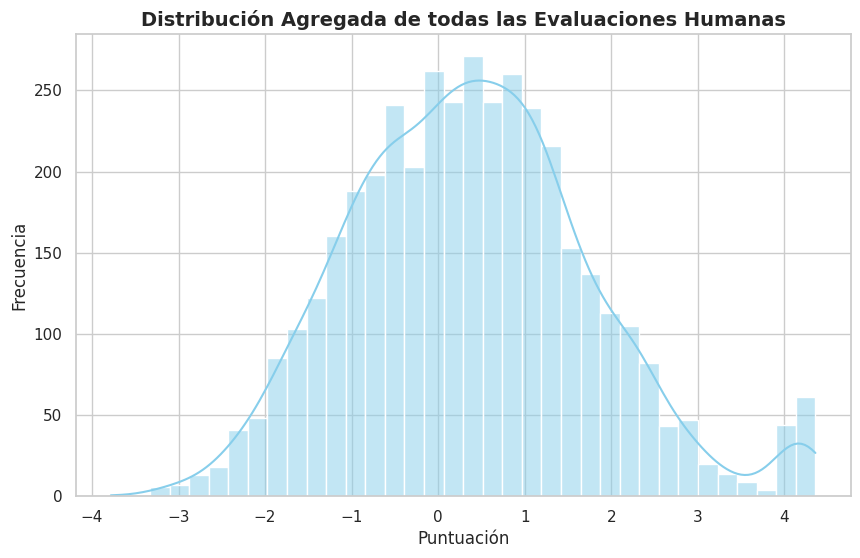

📊 Guardado en: /home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/hist_aggregate.png


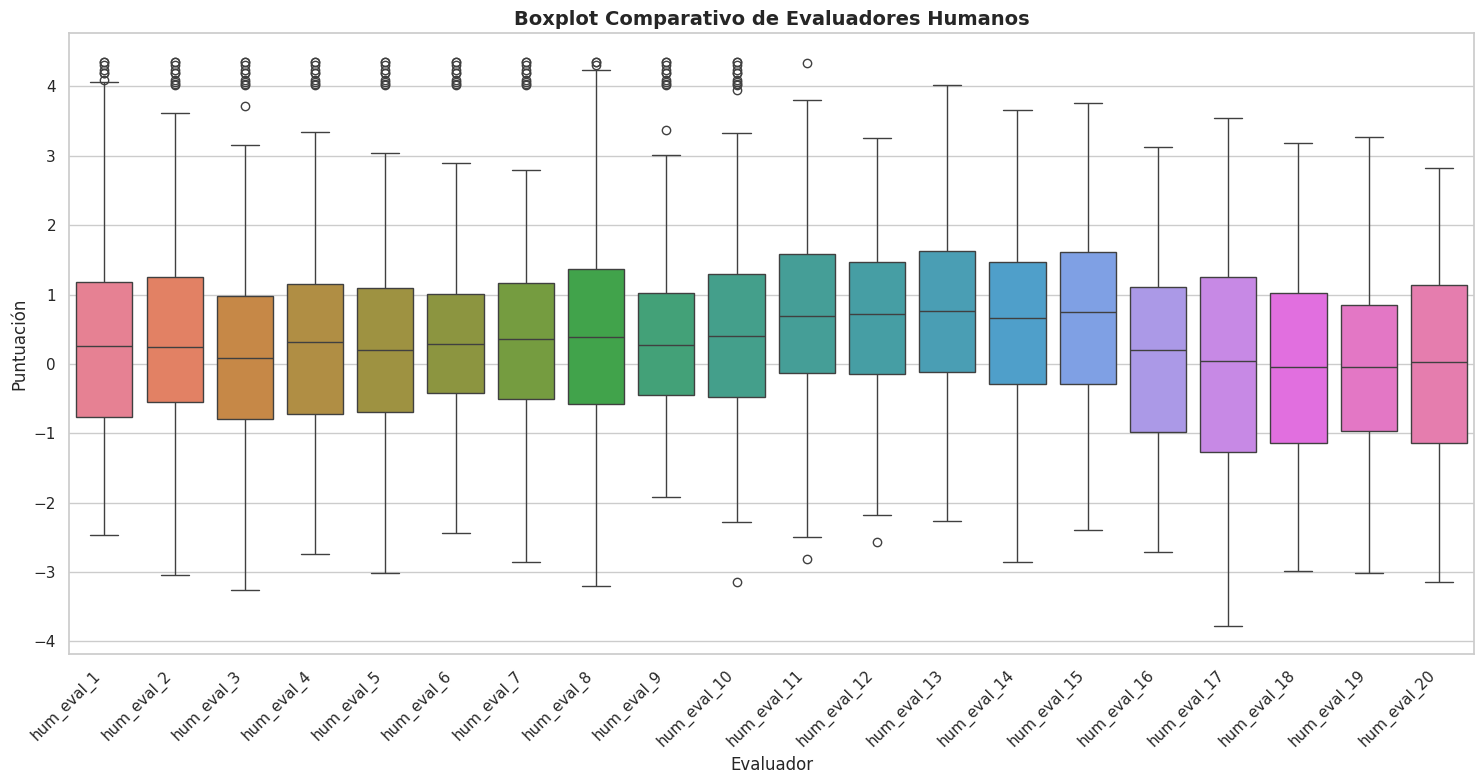

📊 Guardado en: /home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/boxplot_comparative.png


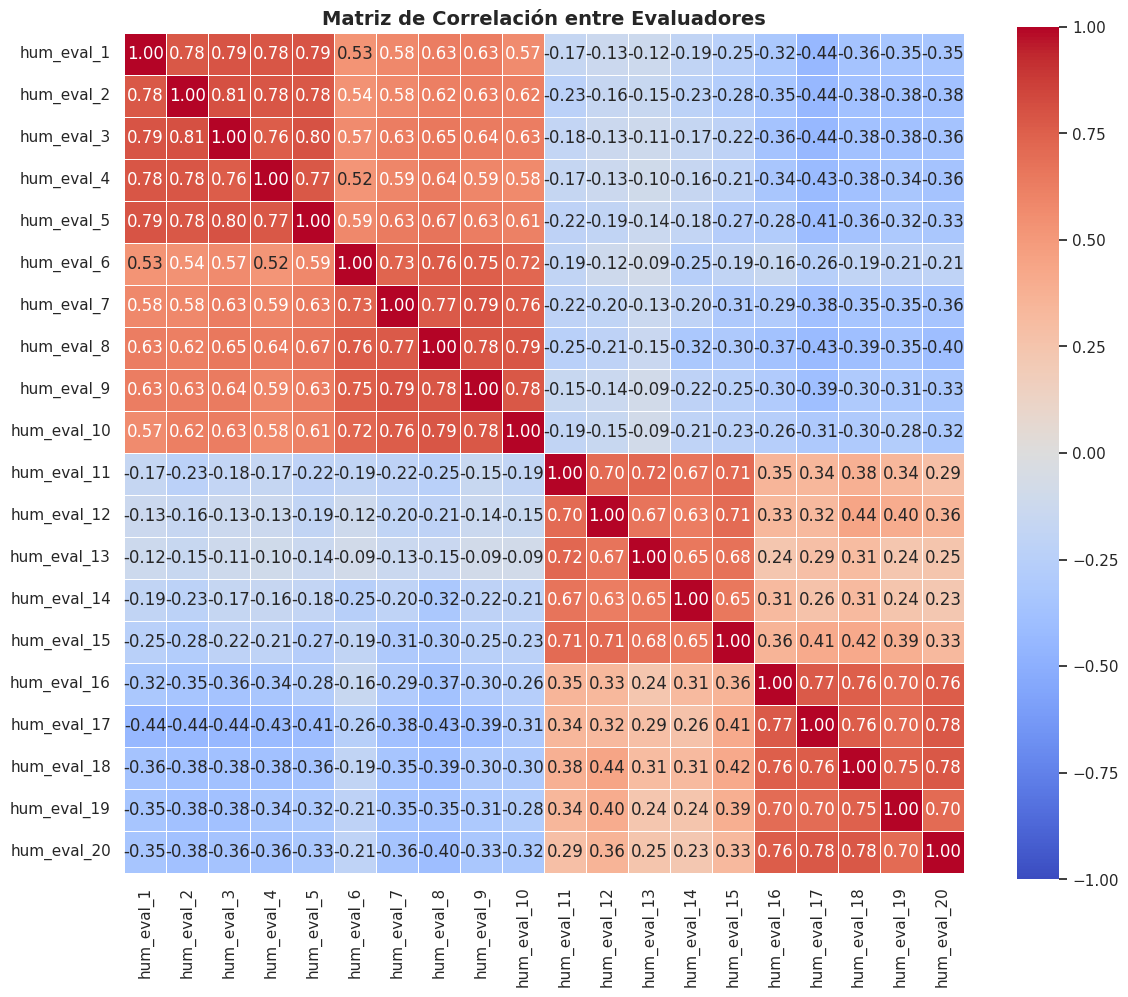

📊 Guardado en: /home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/heatmap_correlation.png


In [52]:
# --- Figura 1: Histograma Agregado ---
# (200 x 20 = 4,000 valores aplanados en una sola distribución)
plt.figure(figsize=(10, 6))
sns.histplot(df.filter(like='hum_eval').values.flatten(), kde=True, color='skyblue')
plt.title('Distribución Agregada de todas las Evaluaciones Humanas', fontsize=14, fontweight='bold')
plt.xlabel('Puntuación')
plt.ylabel('Frecuencia')
plt.savefig(f'{IMG_PATH}hist_aggregate.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Guardado en: {IMG_PATH}hist_aggregate.png")

# --- Figura 2: Boxplot Comparativo ---
plt.figure(figsize=(15, 8))
sns.boxplot(data=df.filter(like='hum_eval'))
plt.title('Boxplot Comparativo de Evaluadores Humanos', fontsize=14, fontweight='bold')
plt.xlabel('Evaluador')
plt.ylabel('Puntuación')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{IMG_PATH}boxplot_comparative.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Guardado en: {IMG_PATH}boxplot_comparative.png")

# --- Figura 3: Heatmap de Correlación ---
plt.figure(figsize=(12, 10))
corr_matrix = df.filter(like='hum_eval').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Matriz de Correlación entre Evaluadores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{IMG_PATH}heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Guardado en: {IMG_PATH}heatmap_correlation.png")

### Interpretación: Boxplot Comparativo y Heatmap de Correlación

---

#### Lectura del Boxplot

Observemos el boxplot comparativo de los 20 evaluadores con atención a tres características:

**1. Alineación de medianas (línea horizontal dentro de cada caja):**

Las medianas **no** son uniformes. Se observan dos comportamientos:
- **Evaluadores 1–10:** Las medianas se sitúan aproximadamente entre $0.2$ y $0.5$. Son evaluadores con un sesgo **ligeramente positivo** — tienden a considerar que las respuestas del modelo son "aceptables a buenas".
- **Evaluadores 11–15:** Las medianas suben a la franja $0.5$–$0.8$, sugiriendo evaluadores **más generosos** en sus puntuaciones.
- **Evaluadores 16–20:** Las medianas caen cerca de $0.0$, indicando evaluadores **más neutros o estrictos**.

> Esta variación en medianas sugiere que **no todos los evaluadores usan la escala de la misma manera**. Algunos son sistemáticamente más generosos y otros más severos. Esto es un fenómeno conocido como **sesgo del evaluador** (*rater bias*).

**2. Tamaño de las cajas (IQR — dispersión central):**

- Los evaluadores **16–20** tienen cajas notablemente **más anchas** (mayor IQR), lo que indica mayor dispersión en sus puntuaciones. Sus opiniones son más **variables**.
- Los evaluadores **1–10** tienen cajas de tamaño más uniforme y moderado.

**3. Outliers (puntos individuales más allá de los bigotes):**

- Se observan **outliers superiores** consistentes en los evaluadores **1–10**, con puntos agrupados alrededor de $4.0$–$4.4$. Esto confirma lo que `describe()` sugirió: hay un **tope superior** ($\approx 4.36$) en las puntuaciones, y múltiples observaciones lo alcanzan.
- Algunos evaluadores (como **hum_eval_10** y **hum_eval_11**) presentan outliers **inferiores** marcados ($\approx -2.8$ a $-3.2$), indicando evaluaciones excepcionalmente negativas en ciertos prompts.

---

#### Lectura del Heatmap de Correlación

El heatmap revela un patrón **extraordinariamente claro** de estructura latente. Observemos los bloques de color:

**Bloque 1 — Evaluadores 1 a 10 (esquina superior izquierda):**
- Se observa un bloque intensamente **rojo** con correlaciones entre $r = 0.52$ y $r = 0.81$.
- Esto significa que estos 10 evaluadores **están de acuerdo entre sí** de forma consistente. Cuando uno da una puntuación alta, los otros también tienden a hacerlo.
- Las correlaciones más fuertes están entre pares como `hum_eval_2`↔`hum_eval_3` ($r = 0.81$) y `hum_eval_3`↔`hum_eval_5` ($r = 0.80$).

**Bloque 2 — Evaluadores 11 a 15 (centro):**
- Otro bloque **rojo** con correlaciones entre $r = 0.63$ y $r = 0.72$.
- Estos 5 evaluadores también coinciden entre sí, formando un **segundo grupo** con criterios compartidos.

**Bloque 3 — Evaluadores 16 a 20 (esquina inferior derecha):**
- Un tercer bloque **rojo intenso** con correlaciones entre $r = 0.70$ y $r = 0.78$.
- Correlaciones particularmente altas: `hum_eval_16`↔`hum_eval_17` ($r = 0.77$), `hum_eval_17`↔`hum_eval_20` ($r = 0.78$).

**Las zonas azules — Correlaciones negativas entre bloques:**
- La zona **azul** entre el Bloque 1 (eval 1–10) y el Bloque 3 (eval 16–20) muestra correlaciones **negativas** ($r \approx -0.30$ a $-0.44$). Esto es muy revelador: **cuando los evaluadores del grupo 1 dan puntuaciones altas, los del grupo 3 dan puntuaciones bajas, y viceversa**.
- La zona entre el Bloque 1 y el Bloque 2 muestra correlaciones **débilmente negativas** ($r \approx -0.09$ a $-0.25$).

---

#### ¿Qué implica esto? — Factores Latentes

Esta estructura de bloques es evidencia fuerte de **factores latentes** subyacentes:

| Bloque | Evaluadores | Posible interpretación |
|---|---|---|
| **Factor A** | hum_eval 1–10 | Estos evaluadores comparten un criterio de calidad (quizás valoran **coherencia** o **fluidez**). |
| **Factor B** | hum_eval 11–15 | Un segundo criterio compartido (quizás **precisión** o **relevancia**). |
| **Factor C** | hum_eval 16–20 | Un tercer criterio, **opuesto** al Factor A (las correlaciones negativas sugieren que valoran algo diferente, o usan la escala en dirección inversa). |

> **Hipótesis para explorar:** Estos tres bloques podrían corresponder a **dimensiones de evaluación diferentes** (por ejemplo: fluidez vs. precisión vs. creatividad). El Análisis de Componentes Principales (PCA) que realizaremos más adelante debería confirmar si efectivamente existen **3 componentes principales** que explican la variabilidad entre evaluadores.

> **Nota clave:** La correlación negativa entre Bloque 1 y Bloque 3 **no significa que un grupo esté equivocado**. Puede significar que están evaluando **aspectos diferentes** de la calidad de las respuestas, y que esos aspectos están inversamente relacionados en este dataset.

## 6.2. Matriz de Correlación Numérica

### Objetivo

Inspeccionar los **coeficientes de correlación exactos** ($r$) entre los 20 evaluadores humanos para verificar numéricamente los **4 bloques teóricos** que hipotetizamos como factores latentes:

| Factor Latente | Evaluadores (hipótesis) | Concepto |
|---|---|---|
| **Quality** (Calidad) | Subconjunto de `hum_eval_1` – `hum_eval_10` | Coherencia, fluidez, utilidad general |
| **Safety** (Seguridad) | Subconjunto de `hum_eval_1` – `hum_eval_10` | Contenido seguro, no dañino |
| **Creativity** (Creatividad) | `hum_eval_11` – `hum_eval_15` | Originalidad, diversidad de respuestas |
| **Bias** (Sesgo) | `hum_eval_16` – `hum_eval_20` | Imparcialidad, equidad en las respuestas |

### ¿Por qué necesitamos la matriz numérica?

El heatmap del paso anterior nos dio una **visión cualitativa** (colores), pero tiene limitaciones:

1. **Precisión:** Los colores no distinguen bien entre $r = 0.65$ y $r = 0.72$ — ambos se ven como "rojo moderado". Los números exactos sí.
2. **Verificación de umbrales:** Necesitamos confirmar que las correlaciones **intra-bloque** (dentro de un grupo) son significativamente mayores que las correlaciones **inter-bloque** (entre grupos). Por ejemplo:
   - Intra-bloque: esperamos $r \geq 0.50$ (correlación moderada-fuerte).
   - Inter-bloque: esperamos $|r| \leq 0.30$ o correlaciones negativas.
3. **Identificación de sub-bloques:** El bloque de evaluadores 1–10 podría en realidad contener **dos sub-factores** (Quality y Safety). Solo los números exactos revelarán si hay una partición interna.

### Patrón esperado

Si los 4 factores latentes existen, la matriz de correlación debería mostrar una estructura **diagonal por bloques**:

$$
\mathbf{R} \approx \begin{pmatrix}
\boxed{\text{Quality}} & \text{bajo} & \text{bajo} & \text{negativo} \\
\text{bajo} & \boxed{\text{Safety}} & \text{bajo} & \text{negativo} \\
\text{bajo} & \text{bajo} & \boxed{\text{Creativity}} & \text{bajo} \\
\text{negativo} & \text{negativo} & \text{bajo} & \boxed{\text{Bias}}
\end{pmatrix}
$$

Donde los **cuadros** en la diagonal representan correlaciones altas ($r > 0.5$) y las zonas fuera de la diagonal muestran correlaciones bajas o negativas.

> **Herramienta:** Usaremos `pandas.style.background_gradient()` para renderizar la tabla con un gradiente de colores que resalta visualmente los valores altos (rojo) y bajos (azul), pero con los **números exactos** visibles en cada celda.

# 6.2 Matriz de Correlación Numérica (con estilo visual)
corr_matrix = df.filter(like='hum_eval').corr()

corr_matrix.style.background_gradient(cmap='coolwarm').format("{:.2f}")

### Interpretación de la Matriz de Correlación

Con los coeficientes numéricos exactos sobre la mesa, podemos ahora **confirmar o refinar** la hipótesis de factores latentes que planteamos tras el heatmap. Lo que emerge es más matizado — y más interesante — que la partición en 3 bloques que inicialmente sospechábamos.

---

#### Los 4 Bloques Confirmados

La matriz revela **cuatro grupos** de evaluadores con alta correlación interna y patrones distintivos de relación entre sí:

| Bloque | Evaluadores | Correlación intra-bloque ($r$) | Factor Latente Probable |
|---|---|---|---|
| **Bloque 1** | `hum_eval_1` – `hum_eval_5` | $r \approx 0.78 - 0.81$ | **Quality** (Calidad) |
| **Bloque 2** | `hum_eval_6` – `hum_eval_10` | $r \approx 0.72 - 0.79$ | **Safety** (Seguridad) |
| **Bloque 3** | `hum_eval_11` – `hum_eval_15` | $r \approx 0.65 - 0.72$ | **Creativity** (Creatividad) |
| **Bloque 4** | `hum_eval_16` – `hum_eval_20` | $r \approx 0.70 - 0.78$ | **Bias** (Sesgo/Imparcialidad) |

> **Nota clave:** Lo que antes veíamos como un solo bloque rojo (evaluadores 1–10) en realidad contiene **dos sub-factores** distinguibles. Las correlaciones dentro de `hum_eval_1`–`hum_eval_5` ($r \approx 0.78$–$0.81$) son consistentemente **más altas** que las correlaciones entre `hum_eval_1`–`hum_eval_5` y `hum_eval_6`–`hum_eval_10` ($r \approx 0.50$–$0.60$). Esa diferencia de $\Delta r \approx 0.20$ es suficiente para distinguirlos como factores separados.

---

#### Relaciones Entre Bloques: La Estructura Inter-factorial

Más allá de los bloques diagonales, las **zonas fuera de la diagonal** revelan cómo se relacionan los factores entre sí:

**1. Quality ↔ Safety (Bloques 1 y 2): Correlación positiva moderada ($r \approx 0.50 - 0.60$)**

Esta es la relación más fuerte entre bloques distintos. **¿Qué significa?** Los modelos que generan respuestas de alta calidad (coherentes, fluidas, útiles) también tienden a ser seguros (sin contenido dañino). Esto tiene sentido intuitivo:

- Un modelo bien entrenado aprende simultáneamente a ser **útil** y a evitar contenido problemático.
- La calidad y la seguridad son objetivos de entrenamiento que **no compiten** entre sí — son complementarios.

> Sin embargo, $r \approx 0.55$ (no $r \approx 0.80$) confirma que son factores **relacionados pero distintos**: un modelo puede ser coherente pero generar contenido inseguro en ciertos contextos, o ser muy seguro (respuestas conservadoras) pero poco útil.

**2. Quality ↔ Creativity (Bloques 1 y 3): Correlación débilmente negativa ($r \approx -0.10$ a $-0.25$)**

Aquí aparece una tensión interesante. Las respuestas que los evaluadores de **calidad** puntúan alto no son necesariamente las que los de **creatividad** valoran:

- Una respuesta "segura y correcta" puede ser también **predecible y genérica** — baja en creatividad.
- Una respuesta **creativa y original** puede tomar riesgos que los evaluadores de calidad perciben como imprecisiones.

> La correlación es débil (cercana a cero), lo que indica que Quality y Creativity son **dimensiones casi ortogonales** (independientes) — no opuestas, sino simplemente diferentes.

**3. Quality ↔ Bias (Bloques 1 y 4): Correlación negativa moderada ($r \approx -0.30$ a $-0.44$)**

Esta es la relación **más negativa** de la matriz y la más reveladora. **¿Qué podría significar?**

- Los evaluadores de **sesgo** (Bias) detectan patrones de parcialidad en las respuestas. Si un modelo genera respuestas de alta "calidad" según los evaluadores del Bloque 1, los evaluadores del Bloque 4 tienden a detectar **más sesgo** en esas mismas respuestas.
- Una posible explicación: los modelos que optimizan agresivamente la calidad percibida pueden recurrir a **estereotipos** o patrones dominantes en sus datos de entrenamiento, lo cual aumenta el sesgo.
- Alternativa: los evaluadores del Bloque 4 podrían estar usando la escala en **dirección inversa** (puntuaciones altas = más sesgo detectado), lo que naturalmente generaría una correlación negativa con "calidad".

---

#### Resumen Visual de la Estructura Factorial

$$
\begin{array}{c|cccc}
 & \textbf{Quality} & \textbf{Safety} & \textbf{Creativity} & \textbf{Bias} \\
\hline
\textbf{Quality} & \color{red}{+++} & \color{orange}{++} & \color{blue}{-} & \color{blue}{- -} \\
\textbf{Safety} & \color{orange}{++} & \color{red}{+++} & \color{gray}{\sim 0} & \color{blue}{-} \\
\textbf{Creativity} & \color{blue}{-} & \color{gray}{\sim 0} & \color{red}{+++} & \color{gray}{\sim 0} \\
\textbf{Bias} & \color{blue}{- -} & \color{blue}{-} & \color{gray}{\sim 0} & \color{red}{+++} \\
\end{array}
$$

Donde:
- $\color{red}{+++}$ = correlación fuerte positiva (intra-bloque, $r > 0.65$)
- $\color{orange}{++}$ = correlación moderada positiva ($r \approx 0.50 - 0.60$)
- $\color{gray}{\sim 0}$ = correlación débil/negligible ($|r| < 0.15$)
- $\color{blue}{-}$ = correlación débilmente negativa ($r \approx -0.10$ a $-0.25$)
- $\color{blue}{- -}$ = correlación moderadamente negativa ($r \approx -0.30$ a $-0.44$)

---

#### Implicación para el Análisis

La existencia de **4 factores latentes** con esta estructura de correlaciones tiene consecuencias directas para los próximos pasos:

1. **PCA (Análisis de Componentes Principales):** Esperamos que los primeros **4 componentes** capturen la mayor parte de la varianza de las 20 variables `hum_eval`. Si el PCA arroja 4 componentes dominantes, será una **confirmación estadística** de lo que la matriz de correlación nos sugiere visualmente.

2. **Interpretabilidad del modelo:** Podemos pasar de 20 evaluadores individuales (difíciles de interpretar) a **4 dimensiones semánticas** (Quality, Safety, Creativity, Bias) — una reducción de $20 \to 4$ que simplifica enormemente la comunicación de resultados.

3. **Relación Quality-Bias:** La correlación negativa entre estos factores es un hallazgo potencialmente importante para NeuroLingua AI. Sugiere un **trade-off** (compromiso) entre calidad percibida y equidad — un tema activo en la investigación de IA responsable.

## 7. Reducción de Dimensionalidad (PCA) en Métricas Internas

### El problema: $p \gg n$ (muchas más variables que observaciones)

Nuestro dataset contiene **2,980 métricas internas** (`int_metric_1`, ..., `int_metric_2980`) pero solo **200 observaciones** (prompts). Esta situación se conoce como el **problema de alta dimensionalidad** o **"maldición de la dimensionalidad"** (*curse of dimensionality*):

$$
p = 2{,}980 \gg n = 200
$$

Donde:
- $p$ = número de variables (dimensiones)
- $n$ = número de observaciones

**¿Por qué es un problema?**

| Consecuencia | Explicación |
|---|---|
| **Distancias pierden significado** | En espacios de alta dimensionalidad, la distancia entre cualquier par de puntos tiende a ser similar. Los algoritmos de clustering (que dependen de distancias) dejan de funcionar bien. |
| **Overfitting** | Con $p > n$, un modelo de regresión puede ajustar perfectamente los datos de entrenamiento sin aprender ningún patrón real — tiene más parámetros que observaciones. |
| **Coste computacional** | Una matriz de correlación de $2{,}980 \times 2{,}980$ tiene $\approx 4.4$ millones de entradas. Multiplicaciones de matrices escalan como $O(p^2 n)$. |
| **Redundancia** | Es muy probable que muchas de las 2,980 métricas estén **correlacionadas entre sí** (miden aspectos similares del modelo). Podemos condensar esa información. |

---

### La solución: Análisis de Componentes Principales (PCA)

**PCA** (*Principal Component Analysis*) es una técnica de **reducción de dimensionalidad** que transforma las $p$ variables originales en un nuevo conjunto de $k$ variables ($k \ll p$) llamadas **componentes principales**, que capturan la mayor cantidad posible de la **varianza** (información) de los datos.

#### ¿Cómo funciona?

PCA realiza una **rotación** del sistema de coordenadas para alinear los nuevos ejes con las **direcciones de máxima varianza** de los datos:

1. **Componente Principal 1 (PC1):** La dirección en el espacio $p$-dimensional a lo largo de la cual los datos tienen la **mayor dispersión** (máxima varianza). Es una combinación lineal de las $p$ variables originales:

$$
\text{PC}_1 = w_{11} x_1 + w_{12} x_2 + \cdots + w_{1p} x_p = \mathbf{w}_1^T \mathbf{x}
$$

2. **Componente Principal 2 (PC2):** La dirección de máxima varianza **ortogonal** (perpendicular) a PC1.

3. Y así sucesivamente: cada componente es ortogonal a todas las anteriores y captura la máxima varianza restante.

Matemáticamente, PCA descompone la **matriz de covarianza** $\mathbf{C}$ de los datos en sus **eigenvalores** ($\lambda_i$) y **eigenvectores** ($\mathbf{w}_i$):

$$
\mathbf{C} \mathbf{w}_i = \lambda_i \mathbf{w}_i
$$

Donde:
- $\mathbf{C} = \frac{1}{n-1} \mathbf{X}^T \mathbf{X}$ es la matriz de covarianza ($p \times p$)
- $\lambda_i$ = eigenvalor del $i$-ésimo componente (= varianza explicada por ese componente)
- $\mathbf{w}_i$ = eigenvector (= dirección/pesos del componente)

La **varianza explicada** por cada componente como proporción del total es:

$$
\text{Varianza explicada por PC}_i = \frac{\lambda_i}{\sum_{j=1}^{p} \lambda_j}
$$

---

### Requisito Obligatorio: Estandarización con `StandardScaler`

**PCA es sensible a la escala de las variables.** Si una variable tiene un rango de $[0, 1000]$ y otra de $[0, 1]$, la primera dominará completamente las componentes principales simplemente por tener valores más grandes — no porque contenga más información.

**`StandardScaler`** transforma cada variable para que tenga **media 0** y **desviación estándar 1**:

$$
z_i = \frac{x_i - \bar{x}}{s}
$$

Donde:
- $x_i$ = valor original
- $\bar{x}$ = media de la variable
- $s$ = desviación estándar de la variable
- $z_i$ = valor estandarizado (*z-score*)

Después de esta transformación, todas las variables están en la **misma escala**, y PCA puede comparar sus varianzas de forma justa.

> **Regla:** Siempre estandarizar antes de PCA, a menos que las variables ya estén en la misma escala y unidades.

---

### Objetivo de este paso

Ajustaremos PCA sobre las **2,980 métricas internas estandarizadas** con todos los componentes posibles ($k = \min(n, p) = 200$) para observar la **curva de varianza explicada** y determinar cuántos componentes $k$ son suficientes para capturar la mayor parte de la información.

In [ ]:
# --- Paso 7: PCA sobre Métricas Internas ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Filtrar las columnas de métricas internas
int_metric_cols = [c for c in df.columns if c.startswith('int_metric')]
print(f"Número de métricas internas: {len(int_metric_cols)}")

# 2. Estandarizar: media=0, std=1 (OBLIGATORIO antes de PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[int_metric_cols])
print(f"Forma de X_scaled: {X_scaled.shape}")
print(f"  → Media de la primera variable después de escalar: {X_scaled[:, 0].mean():.6f} (≈ 0)")
print(f"  → Std de la primera variable después de escalar:  {X_scaled[:, 0].std():.6f} (≈ 1)")

# 3. Ajustar PCA con TODOS los componentes (para ver la curva completa)
pca = PCA().fit(X_scaled)
print(f"\nComponentes ajustados: {pca.n_components_}")

# 4. Varianza explicada por los primeros 10 componentes
print("\n--- Varianza Explicada (primeros 10 componentes) ---")
for i in range(10):
    var_ratio = pca.explained_variance_ratio_[i]
    var_cumul = pca.explained_variance_ratio_[:i+1].sum()
    print(f"  PC{i+1:2d}: {var_ratio:.4f} ({var_ratio*100:.2f}%)  |  Acumulada: {var_cumul:.4f} ({var_cumul*100:.2f}%)")